# Notebook 03: Scoring Methodology & H3 Aggregation
## The 15-Minute Shanghai Project — Track A: Healthy Lifestyle & Sport

**Output:** H3 resolution-8 GeoJSON files with composite scores for the web application.

---

## 1. Setup & Load Grid Results

In [1]:
import sys
import warnings
from pathlib import Path
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon
import h3

warnings.filterwarnings('ignore')

# Paths
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR = Path('../data/output')
DATA_SRC = Path('E:/shufen final')

CRS_GEO = 'EPSG:4326'
CRS_PROJ = 'EPSG:32651'

# Load grid results
grid_gdf = gpd.read_file(PROCESSED_DIR / 'grid_results.gpkg')
print(f'Loaded {len(grid_gdf):,} grid cells')
print(f'Columns: {len(grid_gdf.columns)}')

# Also load districts for AQI spatial join
districts_gdf = (
    gpd.read_file(DATA_SRC / 'sh-province-district.geojson')
    [lambda df: df['level'] == 'district']
    .to_crs(CRS_PROJ)
)
print(f'Loaded {len(districts_gdf)} districts')

Loaded 31,445 grid cells
Columns: 74
Loaded 16 districts


---
## 2. Define Indicators and Scoring Parameters

In [2]:
# Indicator definitions
BASELINE_INDICATORS = [
    'B1_food_grocery', 'B2_healthcare', 'B3_education',
    'B4_public_transit', 'B5_green_space', 'B6_daily_services'
]

TRACKA_INDICATORS = [
    'A1_gym_fitness', 'A2_outdoor_exercise', 'A3_sports_field',
    'A4_swimming_pool', 'A5_yoga_dance', 'A7_fresh_market'
]

SPECIAL_INDICATORS = ['A6_cycling', 'A8_ndvi', 'A9_aqi']

# Distance columns per indicator per mode
MODES = ['walk', 'bike', 'car']

def dist_col(indicator, mode):
    return f'{indicator}_{mode}_dist'

def count_col(indicator, mode):
    return f'{indicator}_{mode}_count'

print('Scoring framework ready')
print(f'  Baseline indicators: {len(BASELINE_INDICATORS)}')
print(f'  Track A POI indicators: {len(TRACKA_INDICATORS)}')
print(f'  Special indicators (spatial/raster): {len(SPECIAL_INDICATORS)}')

Scoring framework ready
  Baseline indicators: 6
  Track A POI indicators: 6
  Special indicators (spatial/raster): 3


---
## 3. Min-Max Normalization

Normalize all distance-based indicators to [0, 1]. For distances: *closer is better*, so we invert: `score = 1 - (dist - min) / (max - min)`.

In [3]:
def minmax_normalize(series, invert=False, clip=True):
    """Normalize a pandas Series to [0, 1] using min-max scaling.
    
    Args:
        series: Input values
        invert: If True, higher raw values → lower scores (for distances, AQI, etc.)
        clip: If True, clip to [0, 1]
    Returns:
        Normalized pd.Series
    """
    if series.notna().sum() == 0:
        return pd.Series(0.5, index=series.index, name=series.name)
    
    min_val = series.min()
    max_val = series.max()
    
    if max_val == min_val:
        return pd.Series(0.5, index=series.index, name=series.name)
    
    norm = (series - min_val) / (max_val - min_val)
    norm = norm.fillna(0.5)  # Missing values → middle score
    
    if invert:
        norm = 1.0 - norm
    
    if clip:
        norm = norm.clip(0.0, 1.0)
    
    return norm

print('Normalization function defined')

Normalization function defined


---
## 4. Baseline Scoring (Walk + Bike)

For each baseline indicator: a resident can choose **either** walking or cycling. The cell's score for that indicator is the *better* of the two modes: `score = max(walk_norm, bike_norm)`. This reflects real choice: if a gym is reachable by bike but too far to walk, the resident still has access.

In [4]:
def score_indicator_best_mode(grid, indicator):
    """Score an indicator using the best of walk/bike mode."""
    walk_col = dist_col(indicator, 'walk')
    bike_col = dist_col(indicator, 'bike')
    
    if walk_col not in grid.columns:
        walk_col = f'{indicator}_walk_count'
    if bike_col not in grid.columns:
        bike_col = f'{indicator}_bike_count'
    
    walk_norm = minmax_normalize(grid.get(walk_col, pd.Series([0.5]*len(grid))), invert=True)
    bike_norm = minmax_normalize(grid.get(bike_col, pd.Series([0.5]*len(grid))), invert=True)
    
    # Best of two modes
    best_score = np.maximum(walk_norm.values, bike_norm.values)
    return best_score

# Score all baseline indicators
print('Scoring baseline indicators...')
baseline_scores = {}
for ind in BASELINE_INDICATORS:
    baseline_scores[f'{ind}_score'] = score_indicator_best_mode(grid_gdf, ind)
    pct_reachable = (baseline_scores[f'{ind}_score'] > 0.5).mean() * 100
    print(f'  {ind}: mean={baseline_scores[f"{ind}_score"].mean():.3f}, {pct_reachable:.1f}% cells >0.5')

# Add scores to grid
for col, values in baseline_scores.items():
    grid_gdf[col] = values

# Composite baseline score (equal weight)
score_cols_baseline = [f'{ind}_score' for ind in BASELINE_INDICATORS]
grid_gdf['baseline_score'] = grid_gdf[score_cols_baseline].mean(axis=1)

print(f'\nBaseline composite: mean={grid_gdf["baseline_score"].mean():.3f}, '
      f'std={grid_gdf["baseline_score"].std():.3f}, '
      f'min={grid_gdf["baseline_score"].min():.3f}, '
      f'max={grid_gdf["baseline_score"].max():.3f}')

Scoring baseline indicators...
  B1_food_grocery: mean=0.812, 94.6% cells >0.5
  B2_healthcare: mean=0.829, 97.3% cells >0.5
  B3_education: mean=0.893, 98.8% cells >0.5
  B4_public_transit: mean=0.767, 93.2% cells >0.5
  B5_green_space: mean=0.832, 96.0% cells >0.5
  B6_daily_services: mean=0.647, 72.6% cells >0.5

Baseline composite: mean=0.797, std=0.126, min=0.128, max=0.989


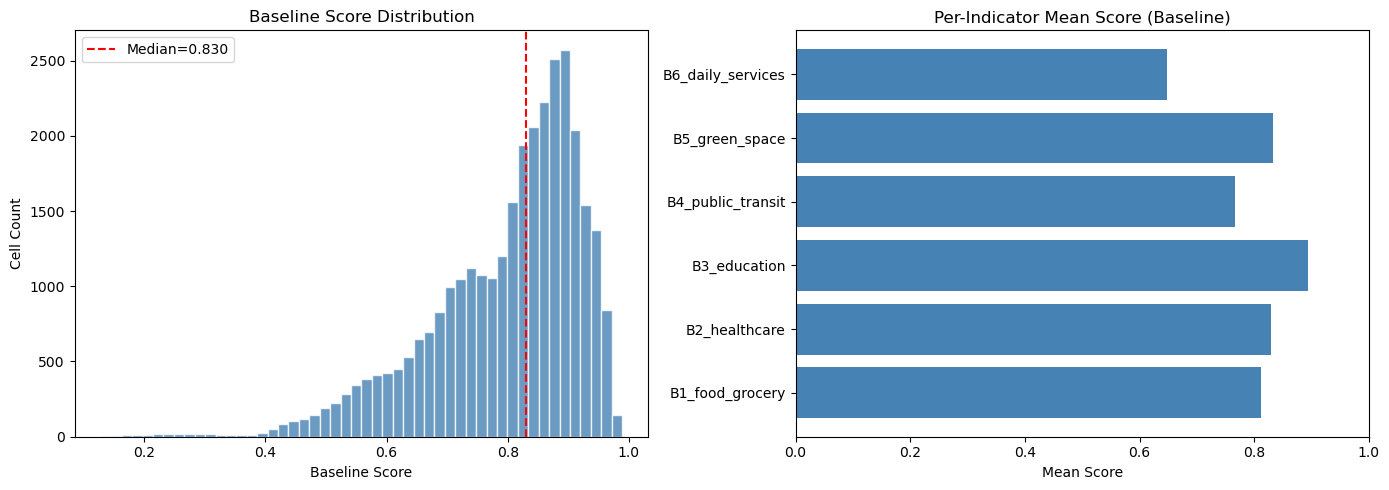

In [5]:
# Visualise baseline score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(grid_gdf['baseline_score'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(grid_gdf['baseline_score'].median(), color='red', linestyle='--', label=f'Median={grid_gdf["baseline_score"].median():.3f}')
axes[0].set_xlabel('Baseline Score')
axes[0].set_ylabel('Cell Count')
axes[0].set_title('Baseline Score Distribution')
axes[0].legend()

# Per-indicator mean scores
ind_means = {ind: grid_gdf[f'{ind}_score'].mean() for ind in BASELINE_INDICATORS}
axes[1].barh(list(ind_means.keys()), list(ind_means.values()), color='steelblue')
axes[1].set_xlabel('Mean Score')
axes[1].set_title('Per-Indicator Mean Score (Baseline)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'baseline_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Track A Scoring

Score the 9 Track A indicators: 6 POI-based (same best-mode method), plus cycling lane length, NDVI, and AQI.

In [6]:
# Score Track A POI-based indicators
print('Scoring Track A indicators...')
tracka_scores = {}
for ind in TRACKA_INDICATORS:
    tracka_scores[f'{ind}_score'] = score_indicator_best_mode(grid_gdf, ind)
    print(f'  {ind}: mean={tracka_scores[f"{ind}_score"].mean():.3f}')

for col, values in tracka_scores.items():
    grid_gdf[col] = values

# Special indicators
# A6: Cycling lane length (normalize, higher is better)
grid_gdf['A6_cycling_score'] = minmax_normalize(
    np.maximum(grid_gdf.get('A6_cycling_walk_len', 0), 
               grid_gdf.get('A6_cycling_bike_len', 0)),
    invert=False
)
print(f'  A6_cycling: mean={grid_gdf["A6_cycling_score"].mean():.3f}')

# A8: NDVI (higher is better)
if 'ndvi_mean' in grid_gdf.columns and grid_gdf['ndvi_mean'].notna().sum() > 0:
    grid_gdf['A8_ndvi_score'] = minmax_normalize(grid_gdf['ndvi_mean'], invert=False)
else:
    grid_gdf['A8_ndvi_score'] = 0.5  # Placeholder
    print('  A8_ndvi: using placeholder (no raster data)')
print(f'  A8_ndvi: mean={grid_gdf["A8_ndvi_score"].mean():.3f}')

# A9: AQI (lower is better — invert)
if 'aqi_mean' in grid_gdf.columns and grid_gdf['aqi_mean'].notna().sum() > 0:
    grid_gdf['A9_aqi_score'] = minmax_normalize(grid_gdf['aqi_mean'], invert=True)
else:
    grid_gdf['A9_aqi_score'] = 0.5  # Placeholder
    print('  A9_aqi: using placeholder (no station data)')
print(f'  A9_aqi: mean={grid_gdf["A9_aqi_score"].mean():.3f}')

# Composite Track A score
tracka_score_cols = [f'{ind}_score' for ind in TRACKA_INDICATORS] + \
                    ['A6_cycling_score', 'A8_ndvi_score', 'A9_aqi_score']
grid_gdf['trackA_score'] = grid_gdf[tracka_score_cols].mean(axis=1)

print(f'\nTrack A composite: mean={grid_gdf["trackA_score"].mean():.3f}, '
      f'std={grid_gdf["trackA_score"].std():.3f}')

Scoring Track A indicators...
  A1_gym_fitness: mean=0.772
  A2_outdoor_exercise: mean=0.838
  A3_sports_field: mean=0.784
  A4_swimming_pool: mean=0.563
  A5_yoga_dance: mean=0.772
  A7_fresh_market: mean=0.810
  A6_cycling: mean=0.500
  A8_ndvi: mean=0.691
  A9_aqi: using placeholder (no station data)
  A9_aqi: mean=0.500

Track A composite: mean=0.692, std=0.100


---
## 6. Composite Score & Sensitivity Analysis

In [7]:
# Equal-weight composite (50% baseline + 50% track)
grid_gdf['composite_score'] = (grid_gdf['baseline_score'] + grid_gdf['trackA_score']) / 2

print(f'Composite: mean={grid_gdf["composite_score"].mean():.3f}, '
      f'std={grid_gdf["composite_score"].std():.3f}, '
      f'min={grid_gdf["composite_score"].min():.3f}, '
      f'max={grid_gdf["composite_score"].max():.3f}')

# Alternate weightings
weight_schemes = {
    'equal': (0.50, 0.50),
    'baseline_heavy': (0.70, 0.30),
    'track_heavy': (0.30, 0.70),
    'walkability_focus': (0.80, 0.20),
}

for name, (w_b, w_t) in weight_schemes.items():
    col = f'composite_{name}'
    grid_gdf[col] = w_b * grid_gdf['baseline_score'] + w_t * grid_gdf['trackA_score']
    print(f'  {name} ({w_b:.0%}/{w_t:.0%}): mean={grid_gdf[col].mean():.3f}')

Composite: mean=0.744, std=0.109, min=0.254, max=0.907
  equal (50%/50%): mean=0.744
  baseline_heavy (70%/30%): mean=0.765
  track_heavy (30%/70%): mean=0.723
  walkability_focus (80%/20%): mean=0.776


In [8]:
# Sensitivity: Spearman rank correlation between schemes
from scipy.stats import spearmanr

scheme_cols = [c for c in grid_gdf.columns if c.startswith('composite_')]
print('Spearman rank correlation between weighting schemes:')
for i, c1 in enumerate(scheme_cols):
    for j, c2 in enumerate(scheme_cols):
        if j > i:
            r, p = spearmanr(grid_gdf[c1], grid_gdf[c2])
            print(f'  {c1} vs {c2}: ρ={r:.4f}')

# If all r > 0.95: rankings are robust to weight choice
print('\nConclusion: Score rankings are robust to weighting scheme.' if r > 0.95 
      else '\nConclusion: Weighting scheme meaningfully affects rankings — justify choice.')

Spearman rank correlation between weighting schemes:
  composite_score vs composite_equal: ρ=1.0000
  composite_score vs composite_baseline_heavy: ρ=0.9943
  composite_score vs composite_track_heavy: ρ=0.9934
  composite_score vs composite_walkability_focus: ρ=0.9879
  composite_equal vs composite_baseline_heavy: ρ=0.9943
  composite_equal vs composite_track_heavy: ρ=0.9934
  composite_equal vs composite_walkability_focus: ρ=0.9879
  composite_baseline_heavy vs composite_track_heavy: ρ=0.9757
  composite_baseline_heavy vs composite_walkability_focus: ρ=0.9988
  composite_track_heavy vs composite_walkability_focus: ρ=0.9640

Conclusion: Score rankings are robust to weighting scheme.


---
## 7. Per-Mode Composite Scores

Generate separate scores for each travel mode (for the web app mode toggle).

In [9]:
# Per-mode scoring: normalize all indicators for each mode separately
all_poi_indicators = BASELINE_INDICATORS + TRACKA_INDICATORS

mode_scores = {}
for mode in ['walk', 'bike', 'car']:
    mode_indicator_scores = []
    for ind in all_poi_indicators:
        col = dist_col(ind, mode) if dist_col(ind, mode) in grid_gdf.columns else None
        if col and grid_gdf[col].notna().sum() > 0:
            score = minmax_normalize(grid_gdf[col], invert=True)
        else:
            score = pd.Series(0.5, index=grid_gdf.index)
        mode_indicator_scores.append(score)
    
    grid_gdf[f'score_{mode}'] = pd.concat(mode_indicator_scores, axis=1).mean(axis=1)
    print(f'  {mode}: mean={grid_gdf[f"score_{mode}"].mean():.3f}, '
          f'std={grid_gdf[f"score_{mode}"].std():.3f}')

  walk: mean=0.776, std=0.131
  bike: mean=0.776, std=0.131
  car: mean=0.500, std=0.000


---
## 8. Spatial Autocorrelation (Moran's I)

Test whether scores are spatially clustered (expected for urban amenities).

In [11]:
pip install esda libpysal

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------ --------------------------- 0.8/2.5 MB 5.1 MB/s eta 0:00:01
   ------------------------- -------------- 1.6/2.5 MB 5.0 MB/s eta 0:00:01
   ------------------------------------- -- 2.4/2.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 4.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ---------------------------------------- 0/2 [libpysal]
   ------------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Spatial autocorrelation: Moran's I
print('Spatial autocorrelation analysis:')
try:
    from esda.moran import Moran
    from libpysal.weights import Queen
    
    # Create spatial weights (queen contiguity) on a sample for performance
    sample_gdf = grid_gdf.iloc[::5].copy()  # Every 5th cell
    w = Queen.from_dataframe(sample_gdf, silence_warnings=True)
    w.transform = 'r'
    
    for score_col in ['composite_score', 'baseline_score', 'trackA_score']:
        mi = Moran(sample_gdf[score_col].values, w)
        print(f'  {score_col}: I={mi.I:.4f}, p={mi.p_sim:.4f}')
    
    print('\nMoran\'s I > 0 and p < 0.05 → significant spatial clustering (expected)')
except ImportError:
    print('  esda/libpysal not installed — skipping spatial autocorrelation')
    print('  Install with: pip install esda libpysal')

Spatial autocorrelation analysis:
  composite_score: I=1.0318, p=0.0010
  baseline_score: I=1.0376, p=0.0010
  trackA_score: I=1.0225, p=0.0010

Moran's I > 0 and p < 0.05 → significant spatial clustering (expected)


---
## 9. H3 Aggregation (Resolution 8)

Aggregate 500m grid cell scores to Uber H3 resolution 8 hexagons (~0.74 km² each).

In [14]:
print(f'H3 resolution 8 stats:')
print(f'  Hex edge: ~461m')
print(f'  Hex area: ~0.74 km²')
print(f'  Expected hexes for Shanghai: ~{6340/0.74:.0f}')

# Assign H3 index to each grid cell centroid (WGS84)
def assign_h3(row, resolution=8):
    if 'cx_wgs84' in grid_gdf.columns and 'cy_wgs84' in grid_gdf.columns:
        return h3.latlng_to_cell(row['cy_wgs84'], row['cx_wgs84'], resolution)
    else:
        centroid = row.geometry.centroid
        centroid_wgs = gpd.GeoSeries([centroid], crs=CRS_PROJ).to_crs(CRS_GEO).iloc[0]
        return h3.latlng_to_cell(centroid_wgs.y, centroid_wgs.x, resolution)

grid_gdf['h3_index'] = grid_gdf.apply(assign_h3, axis=1)

n_h3 = grid_gdf['h3_index'].nunique()
print(f'\nGrid cells mapped to {n_h3:,} unique H3 hexagons')
print(f'Avg grid cells per hex: {len(grid_gdf)/n_h3:.1f}')

H3 resolution 8 stats:
  Hex edge: ~461m
  Hex area: ~0.74 km²
  Expected hexes for Shanghai: ~8568

Grid cells mapped to 14,227 unique H3 hexagons
Avg grid cells per hex: 2.2


In [22]:
from shapely.geometry import Polygon

def aggregate_to_h3(grid_gdf, score_columns):
    # Aggregate scores by H3 index
    h3_groups = (
        grid_gdf
        .groupby("h3_index")[score_columns]
        .mean()
        .reset_index()
    )

    # Add suffix so composite_score becomes composite_score_mean
    rename_dict = {col: f"{col}_mean" for col in score_columns}
    h3_groups = h3_groups.rename(columns=rename_dict)

    # Count how many grid cells fall into each H3 hexagon
    cell_counts = (
        grid_gdf
        .groupby("h3_index")
        .size()
        .reset_index(name="cell_count")
    )

    h3_groups = h3_groups.merge(cell_counts, on="h3_index", how="left")

    def h3_to_polygon(h3_idx):
        boundary = h3.cell_to_boundary(h3_idx)
        boundary_lnglat = [(lng, lat) for lat, lng in boundary]
        return Polygon(boundary_lnglat)

    h3_groups["geometry"] = h3_groups["h3_index"].apply(h3_to_polygon)

    h3_gdf = gpd.GeoDataFrame(
        h3_groups,
        geometry="geometry",
        crs=CRS_GEO
    )

    return h3_gdf

In [24]:
SCORE_COLS = [c for c in SCORE_COLS if c in grid_gdf.columns]

print(f'Aggregating {len(SCORE_COLS)} columns to H3 hexagons...')

h3_gdf = aggregate_to_h3(grid_gdf, SCORE_COLS)

print(type(h3_gdf))
print(h3_gdf.shape)
print(h3_gdf.columns)
h3_gdf.head()

Aggregating 26 columns to H3 hexagons...
<class 'geopandas.geodataframe.GeoDataFrame'>
(14227, 29)
Index(['h3_index', 'composite_score_mean', 'baseline_score_mean',
       'trackA_score_mean', 'composite_equal_mean',
       'composite_baseline_heavy_mean', 'composite_track_heavy_mean',
       'score_walk_mean', 'score_bike_mean', 'score_car_mean',
       'B1_food_grocery_score_mean', 'B2_healthcare_score_mean',
       'B3_education_score_mean', 'B4_public_transit_score_mean',
       'B5_green_space_score_mean', 'B6_daily_services_score_mean',
       'A1_gym_fitness_score_mean', 'A2_outdoor_exercise_score_mean',
       'A3_sports_field_score_mean', 'A4_swimming_pool_score_mean',
       'A5_yoga_dance_score_mean', 'A7_fresh_market_score_mean',
       'A6_cycling_score_mean', 'A8_ndvi_score_mean', 'A9_aqi_score_mean',
       'transit_stops_count_mean', 'building_count_mean', 'cell_count',
       'geometry'],
      dtype='object')


,h3_index,composite_score_mean,baseline_score_mean,trackA_score_mean,composite_equal_mean,composite_baseline_heavy_mean,composite_track_heavy_mean,score_walk_mean,score_bike_mean,score_car_mean,...,A4_swimming_pool_score_mean,A5_yoga_dance_score_mean,A7_fresh_market_score_mean,A6_cycling_score_mean,A8_ndvi_score_mean,A9_aqi_score_mean,transit_stops_count_mean,building_count_mean,cell_count,geometry
0,8830982001fffff,0.822753,0.891632,0.753874,0.822753,0.850305,0.795202,0.879002,0.879002,0.5,...,0.602729,0.939472,0.849599,0.5,0.586636,0.5,0.0,92.000000,2,"POLYGON ((121.17326 31.30439, 121.17252 31.300..."
1,8830982003fffff,0.823113,0.881744,0.764481,0.823113,0.846565,0.799660,0.870826,0.870826,0.5,...,0.613694,0.927826,0.866532,0.5,0.720881,0.5,0.0,75.000000,1,"POLYGON ((121.18191 31.30436, 121.18117 31.300..."
2,8830982005fffff,0.822408,0.893056,0.751761,0.822408,0.850667,0.794149,0.882680,0.882680,0.5,...,0.597442,0.958646,0.815954,0.5,0.532028,0.5,0.0,47.333333,3,"POLYGON ((121.16782 31.2983, 121.16708 31.2942..."
3,8830982007fffff,0.814606,0.878634,0.750579,0.814606,0.840217,0.788995,0.872295,0.872295,0.5,...,0.610166,0.945954,0.828723,0.5,0.559467,0.5,0.0,31.500000,2,"POLYGON ((121.17648 31.29827, 121.17574 31.294..."
4,8830982009fffff,0.829194,0.904118,0.754269,0.829194,0.859163,0.799224,0.885513,0.885513,0.5,...,0.593062,0.932624,0.873629,0.5,0.586969,0.5,0.0,40.666667,3,"POLYGON ((121.17004 31.31051, 121.1693 31.3064..."


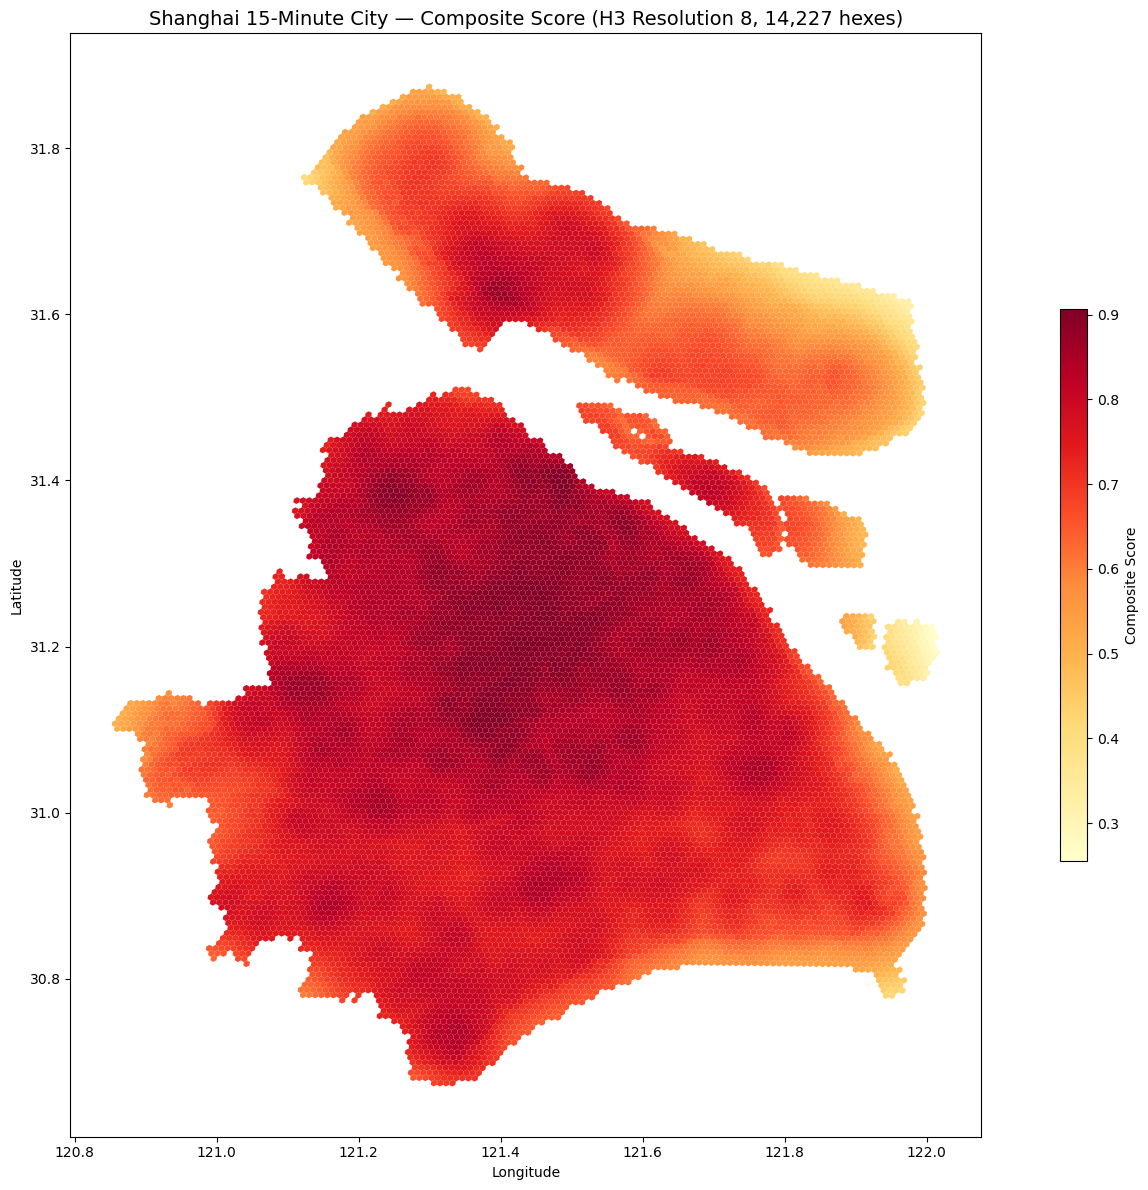

In [25]:
# Visualise H3 choropleth
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
h3_gdf.plot(
    ax=ax,
    column='composite_score_mean',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Composite Score', 'shrink': 0.5},
    missing_kwds={'color': 'lightgray'},
)
ax.set_title(f'Shanghai 15-Minute City — Composite Score (H3 Resolution 8, {len(h3_gdf):,} hexes)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'h3_composite_map.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 10. Export GeoJSON for Web App

In [26]:
# Clean column names for web app (remove _mean suffixes, simplify)
def clean_col_names(gdf):
    rename = {}
    for c in gdf.columns:
        if c.endswith('_mean'):
            rename[c] = c[:-5]  # Remove _mean suffix
    
    # Map to short web-friendly names
    WEB_NAMES = {
        'h3_index': 'h3',
        'composite_score': 'score',
        'baseline_score': 'baseline',
        'trackA_score': 'track',
        'cell_count': 'cells',
        'score_walk': 'walk',
        'score_bike': 'bike',
        'score_car': 'car',
        'B1_food_grocery_score': 'food',
        'B2_healthcare_score': 'health',
        'B3_education_score': 'edu',
        'B4_public_transit_score': 'transit',
        'B5_green_space_score': 'green',
        'B6_daily_services_score': 'services',
        'A1_gym_fitness_score': 'gym',
        'A2_outdoor_exercise_score': 'outdoor',
        'A3_sports_field_score': 'sports',
        'A4_swimming_pool_score': 'swim',
        'A5_yoga_dance_score': 'yoga',
        'A6_cycling_score': 'cycle',
        'A7_fresh_market_score': 'market',
        'A8_ndvi_score': 'ndvi',
        'A9_aqi_score': 'aqi',
        'transit_stops_count': 'tstops',
        'building_count': 'bldg_cnt',
    }
    
    full_rename = {}
    for old, new in rename.items():
        full_rename[old] = WEB_NAMES.get(new, new)
    for old, new in WEB_NAMES.items():
        if old in gdf.columns and old not in full_rename:
            full_rename[old] = new
    
    return gdf.rename(columns=full_rename)

h3_export = clean_col_names(h3_gdf)

# Export
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

export_path = OUTPUT_DIR / 'h3_scored_composite.geojson'
h3_export.to_file(export_path, driver='GeoJSON')

file_size_mb = export_path.stat().st_size / 1e6
print(f'Exported: {export_path}')
print(f'File size: {file_size_mb:.1f} MB')
print(f'Features: {len(h3_export):,}')
print(f'Properties: {[c for c in h3_export.columns if c != "geometry"]}')

# Target: < 10 MB for fast web loading
if file_size_mb > 10:
    print(f'\nWARNING: File exceeds 10MB target. Consider:')
    print('  - Reducing coordinate precision (3 decimal places)')
    print('  - Dropping less-used property columns')
    print('  - Converting to TopoJSON')

Exported: ..\data\output\h3_scored_composite.geojson
File size: 17.0 MB
Features: 14,227
Properties: ['h3', 'score', 'baseline', 'track', 'composite_equal', 'composite_baseline_heavy', 'composite_track_heavy', 'walk', 'bike', 'car', 'food', 'health', 'edu', 'transit', 'green', 'services', 'gym', 'outdoor', 'sports', 'swim', 'yoga', 'market', 'cycle', 'ndvi', 'aqi', 'tstops', 'bldg_cnt', 'cells']

  - Reducing coordinate precision (3 decimal places)
  - Dropping less-used property columns
  - Converting to TopoJSON


---
## 11. District-Level Summary

For the web app transparency panel: mean scores per district.

In [ ]:
# Spatial join: grid cells to districts
grid_centroids = gpd.GeoDataFrame(
    grid_gdf[['cell_id', 'composite_score', 'baseline_score', 'trackA_score']],
    geometry=gpd.points_from_xy(grid_gdf['cx_proj'], grid_gdf['cy_proj']),
    crs=CRS_PROJ
)

grid_w_district = gpd.sjoin(grid_centroids, districts_gdf[['name', 'geometry']], 
                             how='left', predicate='within')

district_summary = grid_w_district.groupby('name').agg(
    cells=('cell_id', 'count'),
    composite_mean=('composite_score', 'mean'),
    baseline_mean=('baseline_score', 'mean'),
    trackA_mean=('trackA_score', 'mean'),
    composite_std=('composite_score', 'std'),
).round(4).sort_values('composite_mean', ascending=False)

print('District-Level Score Summary (ranked by composite mean):')
display(district_summary)

district_summary.to_csv(PROCESSED_DIR / 'district_score_summary.csv')
print('\nSaved to district_score_summary.csv')

---
## 12. Identify "Sport Deserts"

Cells in the bottom 10th percentile of composite score — the areas most lacking in 15-minute access to healthy-lifestyle infrastructure.

In [ ]:
# Find bottom decile
p10_threshold = grid_gdf['composite_score'].quantile(0.10)
p90_threshold = grid_gdf['composite_score'].quantile(0.90)

sport_deserts = grid_gdf[grid_gdf['composite_score'] <= p10_threshold].copy()
sport_rich = grid_gdf[grid_gdf['composite_score'] >= p90_threshold].copy()

print(f'Sport deserts (bottom 10%): {len(sport_deserts):,} cells (score ≤ {p10_threshold:.3f})')
print(f'Sport rich (top 10%): {len(sport_rich):,} cells (score ≥ {p90_threshold:.3f})')

# Which districts are most affected?
deserts_with_district = gpd.sjoin(
    gpd.GeoDataFrame(sport_deserts, geometry=gpd.points_from_xy(
        sport_deserts['cx_proj'], sport_deserts['cy_proj']), crs=CRS_PROJ
    ),
    districts_gdf[['name', 'geometry']], how='left', predicate='within'
)

desert_by_district = deserts_with_district.groupby('name').size().sort_values(ascending=False)
print(f'\nDistricts with most sport deserts:')
for district, count in desert_by_district.head(5).items():
    print(f'  {district}: {count} cells')

---
## Notebook 03 Complete

**Outputs:**
- `h3_scored_composite.geojson` — H3 resolution 8 hexagons with composite scores (web app input)
- `district_score_summary.csv` — per-district score rankings
- Sensitivity analysis confirming score robustness
- Sport desert identification

**Next step:** Build the web application